# Double Descent — Extensions

Two extensions to the main experiment:

1. **Gradient descent vs closed form** — gradient descent from zero
   initialization recovers the minimum-norm solution (implicit
   regularization), reproducing the same double descent curve.
2. **Effect of noise** — increasing the label noise raises the height of
   the interpolation peak.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")

from double_descent import (
    generate_data, fit_least_squares, fit_gradient_descent,
    predict, mse, run_experiment,
)

SEED = 0

# same modern plotting style as the main notebook
modern_palette = ["#2563eb", "#f59e0b", "#10b981", "#8b5cf6", "#ef4444"]
mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "savefig.dpi": 150, "savefig.bbox": "tight", "savefig.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#888888", "axes.linewidth": 0.8,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#cccccc", "grid.linewidth": 0.6, "grid.alpha": 0.4,
    "lines.linewidth": 2.0, "lines.markersize": 5,
    "axes.prop_cycle": mpl.cycler(color=modern_palette),
    "legend.frameon": False, "legend.fontsize": 10,
})

In [2]:
# same configuration as the main experiment
D = 200
n_train = 40
n_test = 1000
noise_std = 0.5
n_trials = 50

d_grid = sorted(set(
    list(range(1, n_train - 5)) +
    list(range(n_train - 5, n_train + 6)) +
    list(range(n_train + 6, D + 1, 4))
))
d_arr = np.array(d_grid)

## 5. Gradient descent vs closed form

### 5.1 Single check at one over-parameterized complexity

We pick `d = 80` (well above the threshold, so the problem is
over-parameterized) and compare two solutions on the same data:
- the closed-form minimum-norm solution (pseudoinverse),
- gradient descent started from `w = 0`.

If implicit regularization holds, the two weight vectors should be almost
identical, and their test errors should match.

In [3]:
rng = np.random.default_rng(SEED)
X_train, y_train, X_test, y_test, _ = generate_data(n_train, n_test, D, noise_std, rng)

d = 80
Xtr, Xte = X_train[:, :d], X_test[:, :d]

w_closed = fit_least_squares(Xtr, y_train)
w_gd = fit_gradient_descent(Xtr, y_train, n_steps=20000)

print(f"||w_closed||              = {np.linalg.norm(w_closed):.4f}")
print(f"||w_gd||                  = {np.linalg.norm(w_gd):.4f}")
print(f"||w_gd - w_closed||       = {np.linalg.norm(w_gd - w_closed):.4e}")
print()
print(f"test MSE closed form      = {mse(y_test, predict(Xte, w_closed)):.4f}")
print(f"test MSE gradient descent = {mse(y_test, predict(Xte, w_gd)):.4f}")

||w_closed||              = 0.8070
||w_gd||                  = 0.8070
||w_gd - w_closed||       = 2.3910e-15

test MSE closed form      = 1.5929
test MSE gradient descent = 1.5929


### 5.2 Double descent curve: GD vs closed form

We now compute both solutions across the whole grid of complexities `d`
(single dataset, for speed) and overlay the two test-error curves.

Away from the threshold the two curves coincide. Near the threshold, where
the problem is ill-conditioned and GD converges slowly, the fixed number of
steps acts like early stopping (a mild regularization), so the GD peak can
be a bit lower — an interesting example of implicit regularization.

findfont: Failed to find font weight semibold, now using 700.


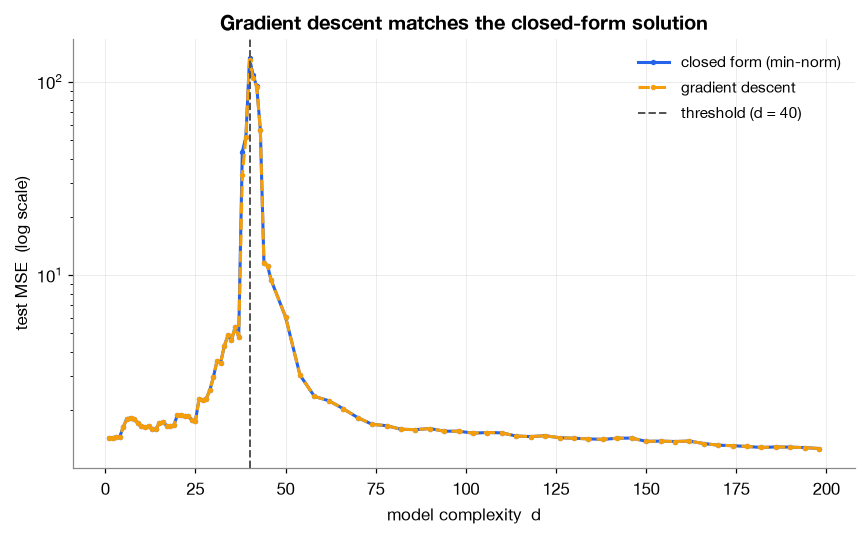

In [4]:
# both solutions over the grid (single trial).
gd_test = []
cf_test = []
for d in d_grid:
    Xtr, Xte = X_train[:, :d], X_test[:, :d]
    w_cf = fit_least_squares(Xtr, y_train)
    w_gd = fit_gradient_descent(Xtr, y_train, n_steps=20000)
    cf_test.append(mse(y_test, predict(Xte, w_cf)))
    gd_test.append(mse(y_test, predict(Xte, w_gd)))

plt.figure(figsize=(8, 5))
plt.plot(d_arr, cf_test, marker=".", label="closed form (min-norm)")
plt.plot(d_arr, gd_test, marker=".", linestyle="--", label="gradient descent")
plt.axvline(n_train, color="#555555", linestyle="--", linewidth=1.3,
            label=f"threshold (d = {n_train})")
plt.yscale("log")
plt.xlabel("model complexity  d")
plt.ylabel("test MSE  (log scale)")
plt.title("Gradient descent matches the closed-form solution")
plt.legend()
plt.tight_layout()
plt.savefig("figures/gd_vs_closed.png")
plt.show()

## 6. Effect of noise

We re-run the closed-form least squares experiment for several values of the
label noise. We expect the interpolation peak to grow with the noise level:
the explosion at the threshold multiplies the residual variance, so more
noise means a taller peak. (Even at zero noise a small peak remains, caused
by the model misspecification from the unused features.)

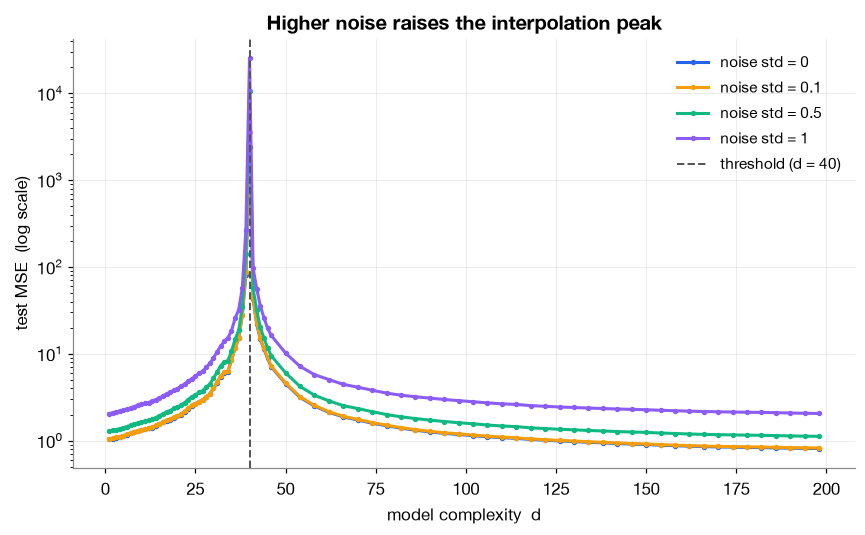

In [5]:
# sweep the noise level (closed-form least squares).
noise_values = [0.0, 0.1, 0.5, 1.0]

plt.figure(figsize=(8, 5))
for sigma in noise_values:
    res = run_experiment(d_grid, n_train, n_test, D, sigma,
                         n_trials, lam=1e-2, seed=SEED)
    plt.plot(d_arr, res["ls_test"], marker=".", label=f"noise std = {sigma:g}")
plt.axvline(n_train, color="#555555", linestyle="--", linewidth=1.3,
            label=f"threshold (d = {n_train})")
plt.yscale("log")
plt.xlabel("model complexity  d")
plt.ylabel("test MSE  (log scale)")
plt.title("Higher noise raises the interpolation peak")
plt.legend()
plt.tight_layout()
plt.savefig("figures/noise.png")
plt.show()